**Importing Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

**Importing Data Set**

In [ ]:
dataset=pd.read_csv("/content/heart_disease_UCI.csv")

In [ ]:
dataset.shape

(303, 14)

In [ ]:
dataset.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1




1.   age
2.   sex (1=male; 0=female)


3.   chest pain type(4 values)
4.   resting blood pressure


5.  serum cholestrol in mg/dl
6.  fasting blood sugar > 120 mg/dl


7.   resting electrocardiographic results (values 0,1,2)
8.   maximum heart rate achieved

9.   exercise induced angina
10.   oldpeak = ST depression induced by exercise relative to rest

11.   the slope of the peak exercise ST segment
12.   number of major vessels (0-3) colored by flourosopy

13.   thal: 3 = normal; 6 = fixed defect; 7 = reversable defect (thallium heart scan or stress test)
14.   target (0 = no heart disease; 1 = heart disease)


In [ ]:
dataset.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


**Checking the null values in the df**

In [ ]:
dataset.isnull().sum()#there are no null values in the df

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

**Replacing the missing values**

In [ ]:
dataset.fillna(method='ffill', inplace=True)

# Save the cleaned df
dataset.to_csv('my_cleaned_df.csv', index=False)

In [ ]:
df=pd.read_csv("/content/my_cleaned_df.csv")

In [ ]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Unique values

In [ ]:
for col in df.columns:
    print(col, len(df[col].unique()))

age 41
sex 2
cp 4
trestbps 49
chol 152
fbs 2
restecg 3
thalach 91
exang 2
oldpeak 40
slope 3
ca 5
thal 4
target 2


In [ ]:
means = df.mean()
print(means)

age          54.366337
sex           0.683168
cp            0.966997
trestbps    131.623762
chol        246.264026
fbs           0.148515
restecg       0.528053
thalach     149.646865
exang         0.326733
oldpeak       1.039604
slope         1.399340
ca            0.729373
thal          2.313531
target        0.544554
dtype: float64


In [ ]:
medians = df.median()
print(medians)

age          55.0
sex           1.0
cp            1.0
trestbps    130.0
chol        240.0
fbs           0.0
restecg       1.0
thalach     153.0
exang         0.0
oldpeak       0.8
slope         1.0
ca            0.0
thal          2.0
target        1.0
dtype: float64


In [ ]:
modes = df.mode()

# Iterate over each column and print the mode
for column in modes.columns:
    print(f"Mode of {column}: {modes[column][0]}")

Mode of age: 58.0
Mode of sex: 1.0
Mode of cp: 0.0
Mode of trestbps: 120.0
Mode of chol: 197
Mode of fbs: 0.0
Mode of restecg: 1.0
Mode of thalach: 162.0
Mode of exang: 0.0
Mode of oldpeak: 0.0
Mode of slope: 2.0
Mode of ca: 0.0
Mode of thal: 2.0
Mode of target: 1.0


In [ ]:
maxi = df.max()
print(maxi)

age          77.0
sex           1.0
cp            3.0
trestbps    200.0
chol        564.0
fbs           1.0
restecg       2.0
thalach     202.0
exang         1.0
oldpeak       6.2
slope         2.0
ca            4.0
thal          3.0
target        1.0
dtype: float64


In [ ]:
mini = df.min()
print(mini)

age          29.0
sex           0.0
cp            0.0
trestbps     94.0
chol        126.0
fbs           0.0
restecg       0.0
thalach      71.0
exang         0.0
oldpeak       0.0
slope         0.0
ca            0.0
thal          0.0
target        0.0
dtype: float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
print(df.corr()["target"].abs().sort_values(ascending=False))

target      1.000000
exang       0.436757
cp          0.433798
oldpeak     0.430696
thalach     0.421741
ca          0.391724
slope       0.345877
thal        0.344029
sex         0.280937
age         0.225439
trestbps    0.144931
restecg     0.137230
chol        0.085239
fbs         0.028046
Name: target, dtype: float64


**From the above information it shows that most columns are moderately correlated with target, but 'fbs' is very weakly correlated.**

**Finding the corelation between the variables**

In [ ]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


**Representing the coorelation variables in heatmap**

<Axes: >

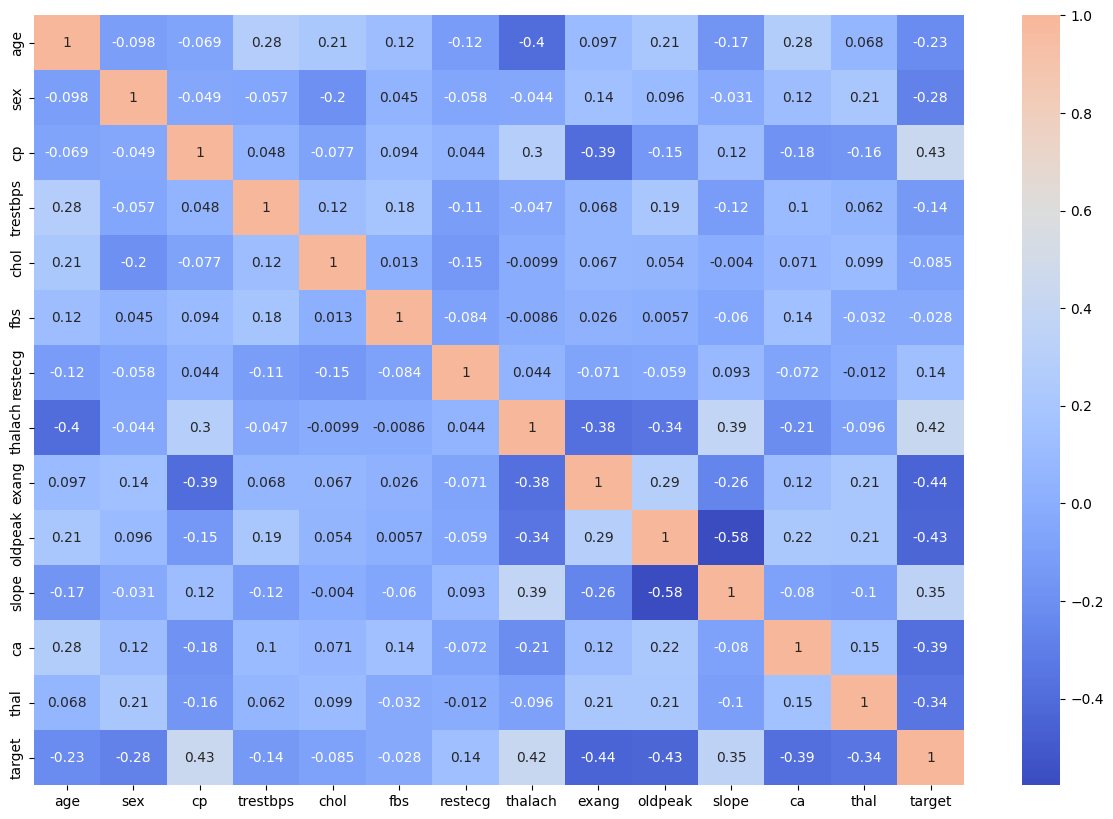

In [ ]:
f, ax = plt.subplots(figsize=(15, 10))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',center=0.6)
#plt. savefig("heatmap.png")
#files. download("heatmap.png")

array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'cp'}>,
        <Axes: title={'center': 'trestbps'}>],
       [<Axes: title={'center': 'chol'}>,
        <Axes: title={'center': 'fbs'}>,
        <Axes: title={'center': 'restecg'}>,
        <Axes: title={'center': 'thalach'}>],
       [<Axes: title={'center': 'exang'}>,
        <Axes: title={'center': 'oldpeak'}>,
        <Axes: title={'center': 'slope'}>,
        <Axes: title={'center': 'ca'}>],
       [<Axes: title={'center': 'thal'}>,
        <Axes: title={'center': 'target'}>, <Axes: >, <Axes: >]],
      dtype=object)

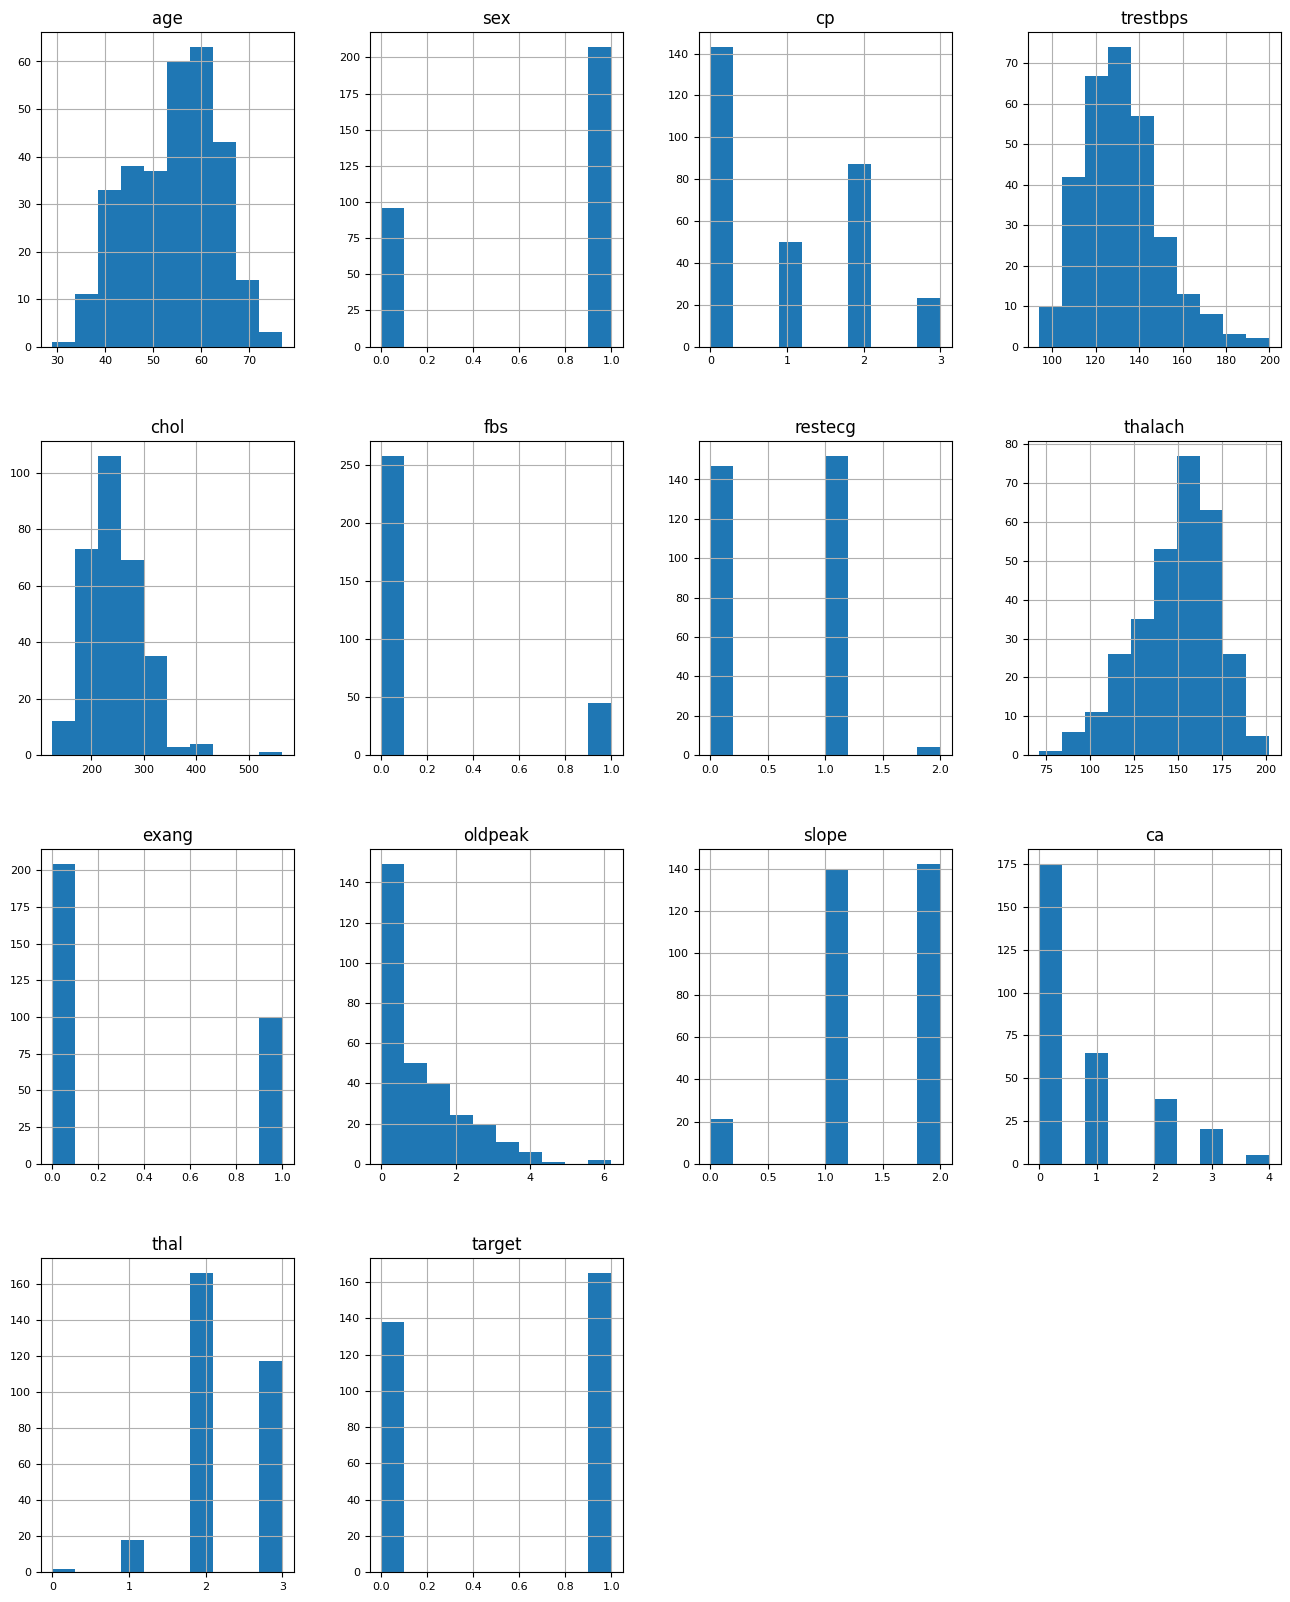

In [ ]:
df.hist(figsize=(16, 20), xlabelsize=8, ylabelsize=8)

**Analysing the target variable**

In [ ]:
df["target"].unique()

array([1, 0])

Clearly, this is a classification problem, with the target variable having values '0' and '1'

In [ ]:
df["target"].describe()

count    303.000000
mean       0.544554
std        0.498835
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: target, dtype: float64

**We will analyse all other features**

**Analysing 'sex' featutre**

In [ ]:
df['sex'].value_counts()

1    207
0     96
Name: sex, dtype: int64


*   Sex feature have 2 unique features
*   Sex (1= male; 0=female)

In [ ]:
df.groupby(['sex', 'target'])['sex'].count()

sex  target
0    0          24
     1          72
1    0         114
     1          93
Name: sex, dtype: int64

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

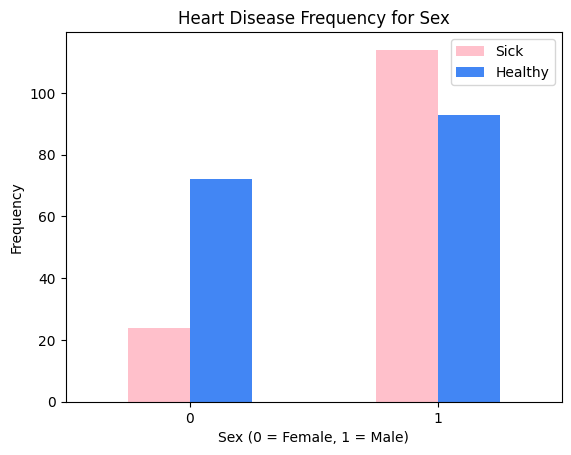

In [ ]:
from google.colab import files
pd.crosstab(df.sex,df.target).plot(kind="bar",color=['pink','#4286f4' ])
plt.title('Heart Disease Frequency for Sex')
plt.xlabel('Sex (0 = Female, 1 = Male)')
plt.xticks(rotation=0)
plt.legend(["Sick", "Healthy"])
plt.ylabel('Frequency')
plt. savefig("D2_gender.png")
files. download("D2_gender.png")
plt.show()


It look's like many females are suffering more from the heartdisease.

In [ ]:
y = df["target"]



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

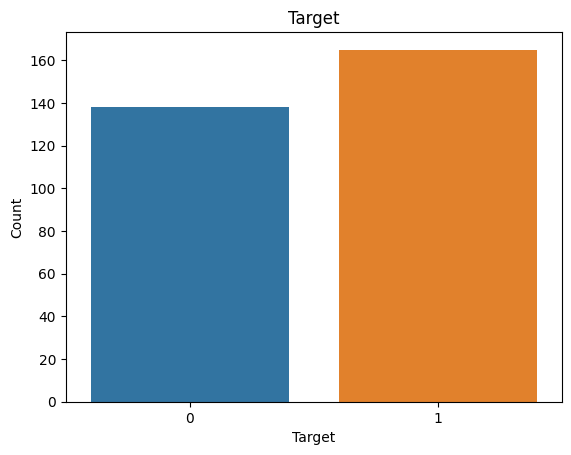

In [ ]:

# create a bar plot of the "restecg" attribute using seaborn
sns.countplot(x="target", data=df)
plt.title("Target")
plt.xlabel("Target")
plt.ylabel("Count")
plt. savefig("D2_target.png")
files. download("D2_target.png")
plt.show()


**Analysing Chest Pain Type Feature**

In [ ]:
df["cp"].unique()

array([3, 2, 1, 0])

We can see that chest pain feature have 0 to 3 values.

From the above barplot we can say persons with chest pain '0' typical angina are less likely to have heart problems.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

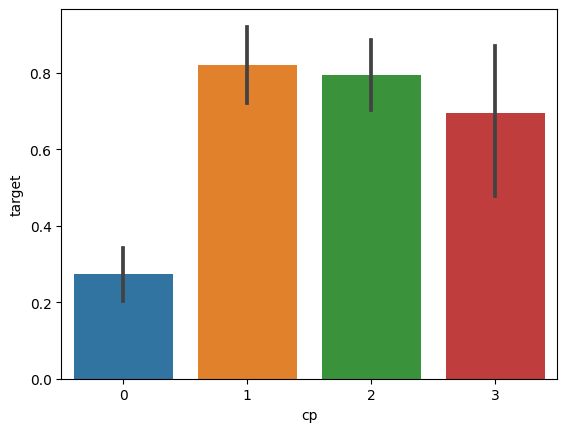

In [ ]:
from google.colab import files
data = df[["cp", "target"]]  # Create a DataFrame with the desired columns
sns.barplot(data=data, x="cp", y="target")  # Pass the combined data to sns.barplot()
plt. savefig("D2_cp.png")
files. download("D2_cp.png")

**Analysing 'Fasting Blood Sugar' feature fbs**

In [ ]:
df['fbs'].unique()

array([1, 0])

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

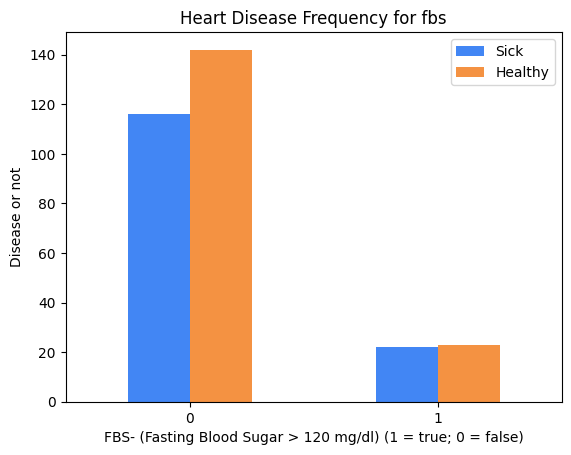

In [ ]:
pd.crosstab(df.fbs,df.target).plot(kind="bar",color=['#4286f4','#f49242'])
plt.title('Heart Disease Frequency for fbs')
plt.xlabel('FBS- (Fasting Blood Sugar > 120 mg/dl) (1 = true; 0 = false)')
plt.xticks(rotation=0)
plt.legend(["Sick", "Healthy"])
plt.ylabel('Disease or not')
plt. savefig("D2_fbs.png")
files. download("D2_fbs.png")
plt.show()

**Analysing the restecg feature**

In [ ]:
df['restecg'].unique()

array([0, 1, 2])

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

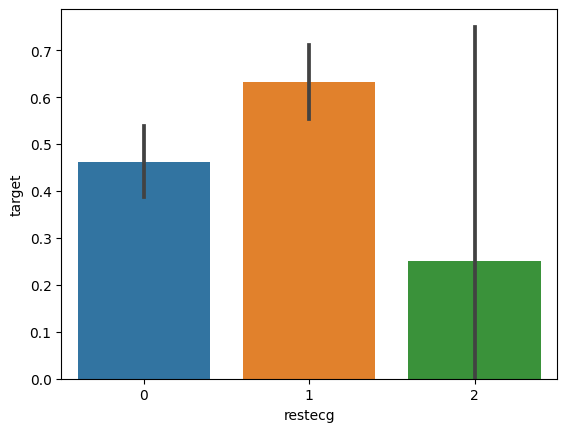

In [ ]:
data = df[["restecg", "target"]]  # Create a DataFrame with the desired columns
sns.barplot(data=data, x="restecg", y="target")  # Pass the combined data to sns.barplot()
plt. savefig("D2_restecg.png")
files. download("D2_restecg.png")

**Analysing the 'exang' feature**

In [ ]:
df['exang'].unique()

array([0, 1])

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

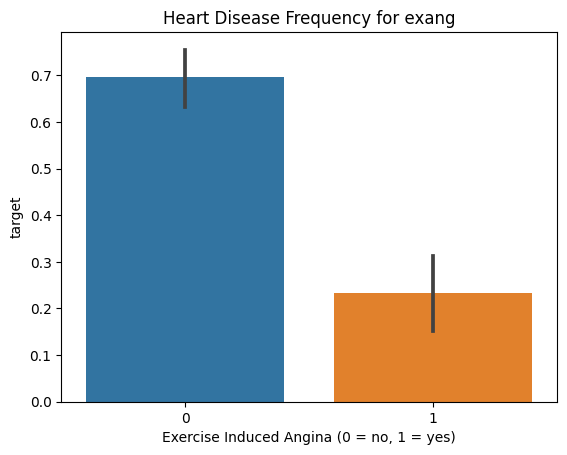

In [ ]:
data = df[["exang", "target"]]  # Create a DataFrame with the desired columns
sns.barplot(data=data, x="exang", y="target")  # Pass the combined data to sns.barplot()
plt.title('Heart Disease Frequency for exang')
plt.xlabel("Exercise Induced Angina (0 = no, 1 = yes)")
plt. savefig("D2_exang.png")
files. download("D2_exang.png")

People having exang=1 means Exercise includes angina are having less chances heart problems.(1 = yes; 0 = no)

In [ ]:
df['oldpeak'].unique()

array([2.3, 3.5, 1.4, 0.8, 0.6, 0.4, 1.3, 0. , 0.5, 1.6, 1.2, 0.2, 1.8,
       1. , 2.6, 1.5, 3. , 2.4, 0.1, 1.9, 4.2, 1.1, 2. , 0.7, 0.3, 0.9,
       3.6, 3.1, 3.2, 2.5, 2.2, 2.8, 3.4, 6.2, 4. , 5.6, 2.9, 2.1, 3.8,
       4.4])

In [ ]:
#sns.barplot(df["oldpeak"],y)
#plt. savefig("oldpeak.png")
#files. download("oldpeak.png")

**Analysing the slope of the peak exercise ST segment**
 (Value 1: upsloping, Value 2: flat, Value 3: downsloping)

In [ ]:
df["slope"].unique()

array([0, 2, 1])

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

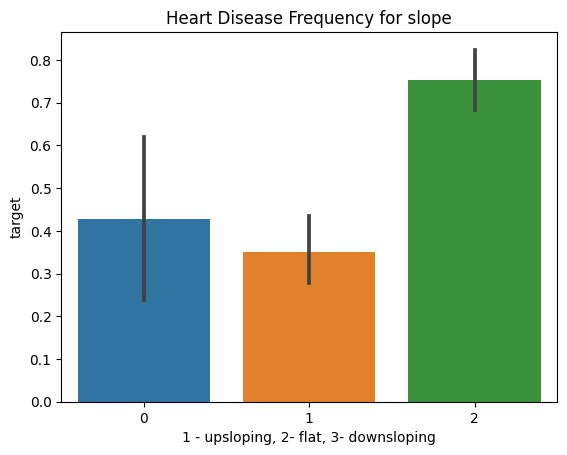

In [ ]:
data = df[["slope", "target"]]  # Create a DataFrame with the desired columns
sns.barplot(data=data, x="slope", y="target")  # Pass the combined data to sns.barplot()
plt.title('Heart Disease Frequency for slope')
plt.xlabel("1 - upsloping, 2- flat, 3- downsloping")
plt. savefig("D2_slope.png")
files. download("D2_slope.png")

from the above information we conclude that slope2 causes much pain than the slope 0 and slope 1.

**Analysing the 'ca' feature** Number of major vessels (0-3) colored by flourosopy

In [ ]:
df["ca"].unique()

array([0, 2, 1, 3, 4])

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

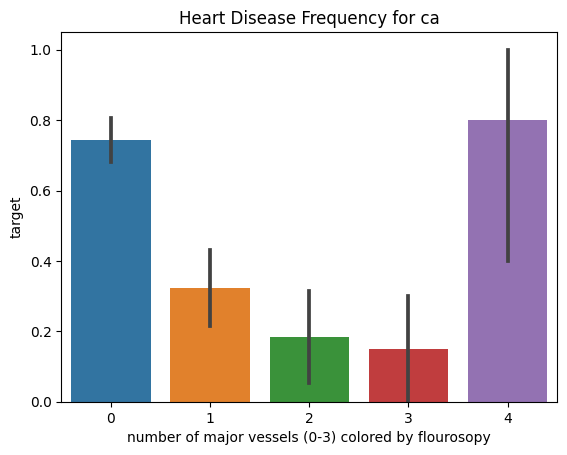

In [ ]:
data = df[["ca", "target"]]  # Create a DataFrame with the desired columns
sns.barplot(data=data, x="ca", y="target")  # Pass the combined data to sns.barplot()
plt.title('Heart Disease Frequency for ca')
plt.xlabel("number of major vessels (0-3) colored by flourosopy")
plt. savefig("D2_ca.png")
files. download("D2_ca.png")

ca=4 has large number of heart patients

In [ ]:
mean_age = df['age'].mean()
print(mean_age)

54.366336633663366


**Analysing the 'thal' feature**

In [ ]:
df["thal"].unique()

array([1, 2, 3, 0])

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

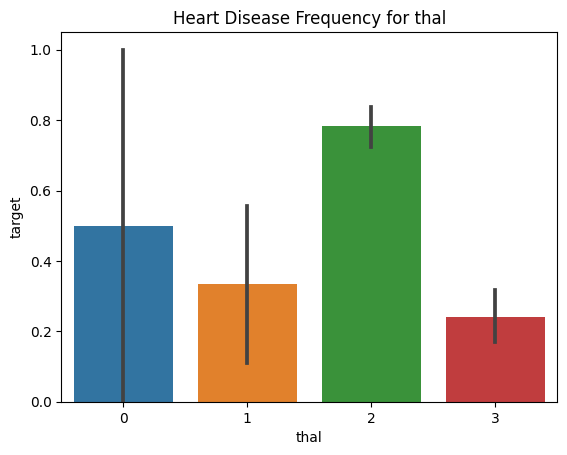

In [ ]:
data =7 df[["thal", "target"]]  # Create a DataFrame with the desired columns
sns.barplot(data=data, x="thal", y="target")  # Pass the combined data to sns.barplot()
plt.title('Heart Disease Frequency for thal')
#plt.xlabel("number of major vessels (0-3) colored by flourosopy")
plt. savefig("D2_thal.png")
files. download("D2_thal.png")

**Splitting the df to Train and Test**

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(["target"],axis=1)
Y = df["target"]

x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.20,random_state=42)

In [ ]:
x_train.shape

(242, 13)

In [ ]:
x_test.shape

(61, 13)

In [ ]:
y_train.shape

(242,)

In [ ]:
y_test.shape

(61,)

In [ ]:
y = df.target

**Building Models**

**Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression()

lr.fit(x_train,y_train)

Y_pred_lr = lr.predict(x_test)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
score_lr = round(accuracy_score(Y_pred_lr,y_test)*100,2)

print("The accuracy score achieved using Logistic Regression is: "+str(score_lr)+" %")

The accuracy score achieved using Logistic Regression is: 88.52 %


**Confusion Matrix**

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
matrix= confusion_matrix(y_test, Y_pred_lr)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

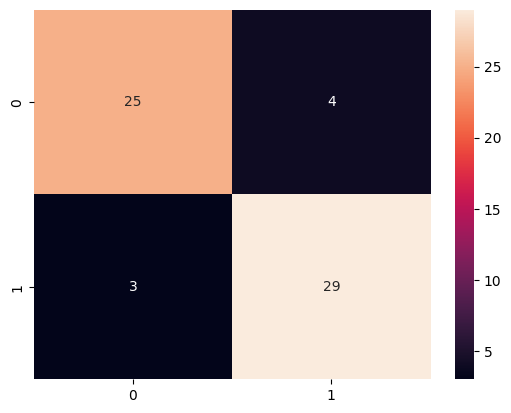

In [ ]:
from google.colab import files
sns.heatmap(matrix,annot = True, fmt = "d")
plt. savefig("D2_logistic.png")
files. download("D2_logistic.png")

In [ ]:
from sklearn.metrics import confusion_matrix
confusion = confusion_matrix(y_test, Y_pred_lr)
print('Confusion Matrix\n')
print(confusion)

Confusion Matrix

[[25  4]
 [ 3 29]]


In [ ]:
from sklearn.metrics import precision_score
precision = precision_score(y_test, Y_pred_lr)
print("Precision: ",precision)

Precision:  0.8787878787878788


In [ ]:
from sklearn.metrics import recall_score
recall = recall_score(y_test, Y_pred_lr)
print("Recall is: ",recall)

Recall is:  0.90625


In [ ]:
print("F1 Score :",(2*precision*recall)/(precision+recall))

F1 Score : 0.8923076923076922


**Miss-classification Rate**

In [ ]:
rate_lr = accuracy_score(Y_pred_lr,y_test)
rate = 1-rate_lr
print(rate)

0.11475409836065575


**Specificity**

In [ ]:
ConfusionMatrix =pd.crosstab(y_test, Y_pred_lr)
print(ConfusionMatrix)

col_0    0   1
target        
0       25   4
1        3  29


In [ ]:
tn=ConfusionMatrix.iloc[0,0]
fp=ConfusionMatrix.iloc[0,1]
fn=ConfusionMatrix.iloc[1,0]
tp=ConfusionMatrix.iloc[1,1]

In [ ]:
specificity_lr = tn/(tn+fp)
print('specificity is:',specificity_lr)

specificity is: 0.8620689655172413


**SVM**

In [ ]:
from sklearn import svm
from sklearn.svm import SVC

sv = svm.SVC(kernel='linear', C=0.1, gamma=0.1)

sv.fit(x_train, y_train)

Y_pred_svm = sv.predict(x_test)

In [ ]:
score_svm = round(accuracy_score(Y_pred_svm,y_test)*100,2)

print("The accuracy score achieved using Linear SVM is: "+str(score_svm)+" %")

The accuracy score achieved using Linear SVM is: 88.52 %


**Confusion Matrix for SVM**

In [ ]:
matrix= confusion_matrix(y_test, Y_pred_svm)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

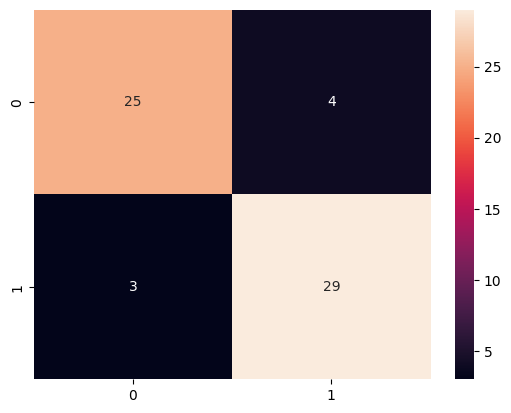

In [ ]:
from google.colab import files
sns.heatmap(matrix,annot = True, fmt = "d")
plt. savefig("D2_svm.png")
files. download("D2_svm.png")

In [ ]:
from sklearn.metrics import recall_score
recall = recall_score(y_test, Y_pred_svm)
print("Recall is: ",recall)

Recall is:  0.90625


In [ ]:
from sklearn.metrics import precision_score
precision = precision_score(y_test, Y_pred_svm)
print("Precision: ",precision)

Precision:  0.8787878787878788


In [ ]:
print("F1 Score :",(2*precision*recall)/(precision+recall))

F1 Score : 0.8923076923076922


**Miss-Classification Rate**

In [ ]:
rate_svm = accuracy_score(Y_pred_svm,y_test)
rate = 1-rate_svm
print(rate)

0.11475409836065575


**Specificity**

In [ ]:
ConfusionMatrix =pd.crosstab(y_test, Y_pred_svm)
print(ConfusionMatrix)

col_0    0   1
target        
0       25   4
1        3  29


In [ ]:
tn=ConfusionMatrix.iloc[0,0]
fp=ConfusionMatrix.iloc[0,1]
fn=ConfusionMatrix.iloc[1,0]
tp=ConfusionMatrix.iloc[1,1]

In [ ]:
specificity_svm = tn/(tn+fp)
print('specificity is:',specificity_svm)

specificity is: 0.8620689655172413


**K Nearest Neighbors**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)
Y_pred_knn=knn.predict(x_test)

In [ ]:
score_knn = round(accuracy_score(Y_pred_knn,y_test)*100,2)

print("The accuracy score achieved using KNN is: "+str(score_knn)+" %")

The accuracy score achieved using KNN is: 63.93 %


**Confusion Matrix for KNN**

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

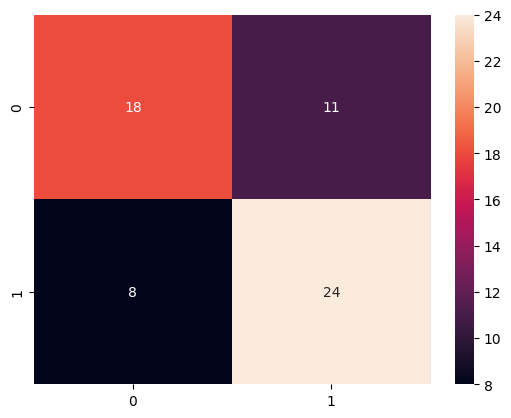

In [ ]:
matrix= confusion_matrix(y_test, Y_pred_knn)
from google.colab import files
sns.heatmap(matrix,annot = True, fmt = "d")
plt. savefig("D2_Knn.png")
files. download("D2_Knn.png")

In [ ]:
from sklearn.metrics import recall_score
recall = recall_score(y_test, Y_pred_knn)
print("Recall is: ",recall)

Recall is:  0.75


In [ ]:
from sklearn.metrics import precision_score
precision = precision_score(y_test, Y_pred_knn)
print("Precision: ",precision)

Precision:  0.6857142857142857


In [ ]:
print("F1 Score :",(2*precision*recall)/(precision+recall))

F1 Score : 0.7164179104477612


**Miss-Classification Rate**

In [ ]:
rate_knn = accuracy_score(Y_pred_knn,y_test)
rate = 1-rate_knn
print(rate)

0.3114754098360656


**Specificity**

In [ ]:
ConfusionMatrix =pd.crosstab(y_test, Y_pred_knn)
print(ConfusionMatrix)

col_0    0   1
target        
0       18  11
1        8  24


In [ ]:
tn=ConfusionMatrix.iloc[0,0]
fp=ConfusionMatrix.iloc[0,1]
fn=ConfusionMatrix.iloc[1,0]
tp=ConfusionMatrix.iloc[1,1]

In [ ]:
specificity_knn = tn/(tn+fp)
print('specificity is:',specificity_knn)

specificity is: 0.6206896551724138


**Naive Bayes**

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(x_train,y_train)

Y_pred_nb = nb.predict(x_test)

In [ ]:
score_nb = round(accuracy_score(Y_pred_nb,y_test)*100,2)

print("The accuracy score achieved using Naive Bayes is: "+str(score_nb)+" %")

The accuracy score achieved using Naive Bayes is: 86.89 %


**Confusion Matrix for Navie bayes**

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

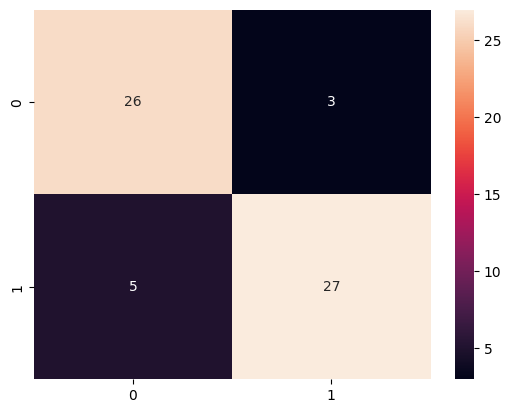

In [ ]:
matrix= confusion_matrix(y_test, Y_pred_nb)
from google.colab import files
sns.heatmap(matrix,annot = True, fmt = "d")
plt. savefig("D2_nb.png")
files. download("D2_nb.png")

In [ ]:
from sklearn.metrics import recall_score
recall = recall_score(y_test, Y_pred_nb)
print("Recall is: ",recall)

Recall is:  0.84375


In [ ]:
from sklearn.metrics import precision_score
precision = precision_score(y_test, Y_pred_nb)
print("Precision: ",precision)

Precision:  0.9


In [ ]:
print("F1 Score :",(2*precision*recall)/(precision+recall))

F1 Score : 0.870967741935484


**Miss-Classification Rate**

In [ ]:
rate_knn = accuracy_score(Y_pred_nb,y_test)
rate = 1- rate_knn
print(rate)

0.1311475409836066


**Specificity**

In [ ]:
ConfusionMatrix =pd.crosstab(y_test, Y_pred_nb)
print(ConfusionMatrix)

col_0    0   1
target        
0       26   3
1        5  27


In [ ]:
tn=ConfusionMatrix.iloc[0,0]
fp=ConfusionMatrix.iloc[0,1]
fn=ConfusionMatrix.iloc[1,0]
tp=ConfusionMatrix.iloc[1,1]

In [ ]:
specificity_nb = tn/(tn+fp)
print('specificity is:',specificity_nb)

specificity is: 0.896551724137931


**Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=4, random_state=42)

dt.fit(x_train, y_train)

y_pred_dt = dt.predict(x_test)

In [ ]:
score_dt = round(accuracy_score(y_pred_dt,y_test)*100,2)

print("The accuracy score achieved using Decision Tree is: "+str(score_dt)+" %")

The accuracy score achieved using Decision Tree is: 80.33 %


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

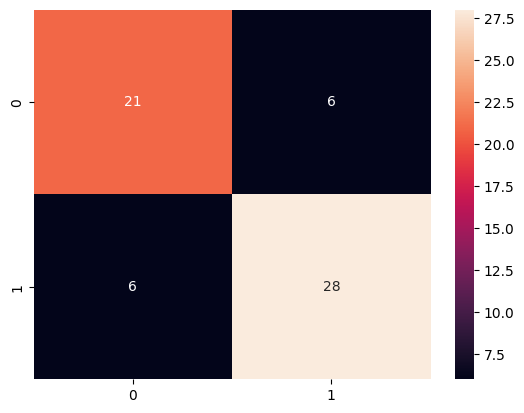

In [ ]:
matrix= confusion_matrix(y_test, y_pred_dt)
from google.colab import files
sns.heatmap(matrix,annot = True, fmt = "d")
plt. savefig("D2_DT.png")
files. download("D2_DT.png")

In [ ]:
from sklearn.metrics import precision_score
precision = precision_score(y_test, y_pred_dt)
print("Precision: ",precision)

Precision:  0.8235294117647058


In [ ]:
from sklearn.metrics import recall_score
recall = recall_score(y_test, y_pred_dt)
print("Recall is: ",recall)

Recall is:  0.8235294117647058


In [ ]:
print("F1 Score :",(2*precision*recall)/(precision+recall))

F1 Score : 0.8235294117647058


In [ ]:
rate_dt = accuracy_score(y_pred_dt,y_test)
rate = 1- rate_dt
print(rate)

0.19672131147540983


**Specificity**

In [ ]:
ConfusionMatrix =pd.crosstab(y_test, y_pred_dt)
print(ConfusionMatrix)

col_0    0   1
target        
0       21   6
1        6  28


In [ ]:
tn=ConfusionMatrix.iloc[0,0]
fp=ConfusionMatrix.iloc[0,1]
fn=ConfusionMatrix.iloc[1,0]
tp=ConfusionMatrix.iloc[1,1]

In [ ]:
specificity_dt = tn/(tn+fp)
print('specificity is:',specificity_dt)

specificity is: 0.7777777777777778


**Random Forest**

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.20,random_state=0)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
randfor = RandomForestClassifier(max_depth=2,n_estimators=100, random_state=0)

randfor.fit(x_train, y_train)

y_pred_rf = randfor.predict(x_test)


In [ ]:
score_rf = round(accuracy_score(y_pred_rf,y_test)*100,2)

print("The accuracy score achieved using Random Forest is: "+str(score_rf)+" %")

The accuracy score achieved using Random Forest is: 88.52 %


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

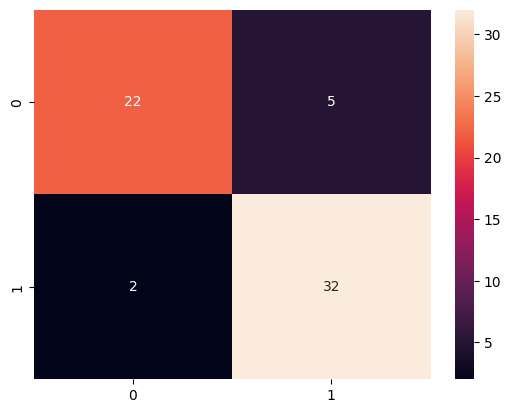

In [ ]:
matrix= confusion_matrix(y_test, y_pred_rf)
from google.colab import files
sns.heatmap(matrix,annot = True, fmt = "d")
plt. savefig("D2_rf.png")
files. download("D2_rf.png")


In [ ]:
from sklearn.metrics import recall_score
recall = recall_score(y_test, y_pred_rf)
print("Recall is: ",recall)

Recall is:  0.9411764705882353


In [ ]:
from sklearn.metrics import precision_score
precision = precision_score(y_test, y_pred_rf)
print("Precision: ",precision)

Precision:  0.8648648648648649


In [ ]:
print("F1 Score :",(2*precision*recall)/(precision+recall))

F1 Score : 0.9014084507042254


**Miss-Classification Rate**

In [ ]:
rate_rf = accuracy_score(y_pred_rf,y_test)
rate = 1- rate_rf
print(rate)

0.11475409836065575


**Specificity**

In [ ]:
ConfusionMatrix =pd.crosstab(y_test, y_pred_rf)
print(ConfusionMatrix)

col_0    0   1
target        
0       22   5
1        2  32


In [ ]:
tn=ConfusionMatrix.iloc[0,0]
fp=ConfusionMatrix.iloc[0,1]
fn=ConfusionMatrix.iloc[1,0]
tp=ConfusionMatrix.iloc[1,1]

In [ ]:
specificity_rf = tn/(tn+fp)
print('specificity is:',specificity_rf)

specificity is: 0.8148148148148148


**K-Fold Cross Validation**

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from numpy import mean
from numpy import std
logreg_kf = LogisticRegression()
cv = KFold(n_splits=5, random_state=100, shuffle=True)
scores = cross_val_score(logreg_kf, X, Y, scoring='accuracy', cv=cv, n_jobs=-1)
acc_lr = mean(scores)
print('Accuracy: %.3f' % (mean(scores)))

Accuracy: 0.835


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from numpy import mean
from numpy import std
svm_kf= svm.SVC(kernel='linear', C=1, gamma=1)
cv = KFold(n_splits=5, random_state=1, shuffle=True)
scores = cross_val_score(svm_kf, X, Y, scoring='accuracy', cv=cv, n_jobs=-1)
print('Accuracy: %.3f' % (mean(scores)))

Accuracy: 0.808


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from numpy import mean
from numpy import std
knn_kf = KNeighborsClassifier(n_neighbors=7)
cv = KFold(n_splits=5, random_state=1, shuffle=True)
scores = cross_val_score(knn_kf, X, Y, scoring='accuracy', cv=cv, n_jobs=-1)
print('Accuracy: %.3f' % (mean(scores)))

Accuracy: 0.666


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from numpy import mean
from numpy import std
nb_kf = GaussianNB()
cv = KFold(n_splits=5, random_state=1, shuffle=True)
scores = cross_val_score(nb_kf, X, Y, scoring='accuracy', cv=cv, n_jobs=-1)
print('Accuracy: %.3f' % (mean(scores)))

Accuracy: 0.845


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from numpy import mean
from numpy import std
Dt_kf = DecisionTreeClassifier(max_depth=4, random_state=0)
cv = KFold(n_splits=5, random_state=1, shuffle=True)
scores = cross_val_score(Dt_kf, X, Y, scoring='accuracy', cv=cv, n_jobs=-1)
print('Accuracy: %.3f' % (mean(scores)))

Accuracy: 0.762


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from numpy import mean
from numpy import std
rf_kf = RandomForestClassifier(max_depth=5,n_estimators=100, random_state=5)
cv = KFold(n_splits=5, random_state=1, shuffle=True)
scores = cross_val_score(rf_kf, X, Y, scoring='accuracy', cv=cv, n_jobs=-1)
print('Accuracy: %.3f' % (mean(scores)))

Accuracy: 0.838


In [ ]:
# initialize an empty list
accuracy = []

# list of algorithms names
classifiers = ['KNN','SVM','Logistic Regression', 'Naive Bayes','Decision Tress','Random forest']

# list of algorithms with parameters
models = [KNeighborsClassifier(n_neighbors=7),svm.SVC(kernel='linear', C=1, gamma=1),LogisticRegression(),
        GaussianNB(),DecisionTreeClassifier(max_depth=4, random_state=0),RandomForestClassifier(max_depth=5,n_estimators=100, random_state=5)]

# loop through algorithms and append the score into the list
for i in models:
    model = i
    model.fit(x_train, y_train)
    score = model.score(x_test, y_test)
    accuracy.append(score)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
summary = pd.DataFrame({'accuracy':accuracy}, index=classifiers)
summary


,accuracy
KNN,0.655738
SVM,0.885246
Logistic Regression,0.934426
Naive Bayes,0.918033
Decision Tress,0.786885
Random forest,0.901639
